In [ ]:
#!pip install squarenet

In [ ]:
from squarenet import SquareNet
from squarenet.sampler import samplepoints
from squarenet.backends import to_backend

## Backend selection

In [ ]:
backend = "jax"
#backend = "torch"

In [8]:
if backend == "torch":
    import torch
if backend == "jax":
    import jax
    import jax.numpy as jnp

## ❒ SquareNet for PyTorch

I. sample a dataset \
as a torch tensor, on the device of your choice

In [9]:
I = 100
N = I*I*I
points = samplepoints("ball", size = (N, 3))
points = to_backend(points, backend = "torch")

type(points)

torch.Tensor

II. Specify backend to the SquareNet

In [10]:
sn = SquareNet(gridshape = (I, I, I), backend = "torch")
sn.fit(points)

Starting gridification... available method [fast, robust, ultimate]
selected fast

=== Carthesian sort ===
(max iter: 1000)
[█████████████████████████████] 1000/1000

=== Final Status ===
succesfully sorted at iteration 19


In [11]:
grided_points = sn.map(points)
type(grided_points)

torch.Tensor

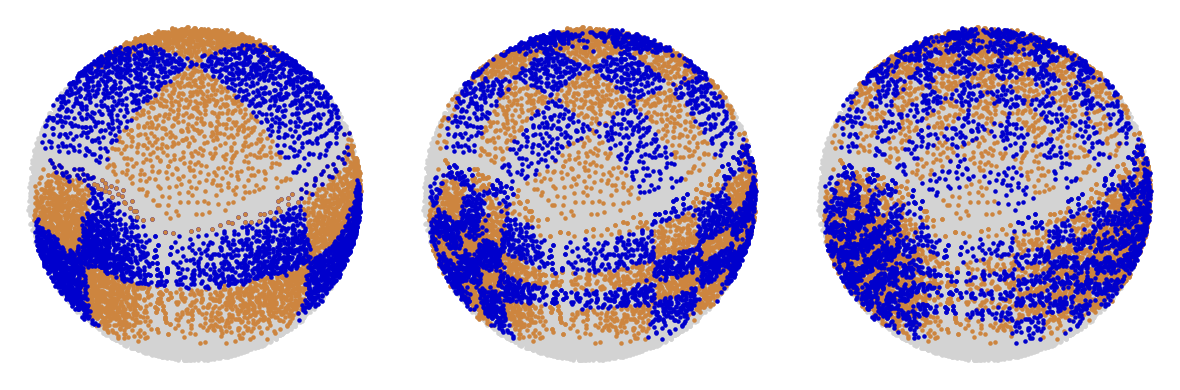

(<Figure size 1200x400 with 3 Axes>, None)

In [12]:
sn.plot(save = False)

## ❒ SquareNet for Jax

In [14]:
I = 100
N = I*I
points = samplepoints("spiky", size = (N, 2))
points = to_backend(points, backend = "jax")

type(points)

jaxlib._jax.ArrayImpl

In [15]:
sn = SquareNet(gridshape = (I, I), backend = "jax")
sn.fit(points, method = "ultimate")

Starting gridification... available method [fast, robust, ultimate]
selected ultimate

=== Carthesian sort ===
(max iter: 2 x 1000 + 4 x 1000 + 1000)
[█████████████████████████████] 1000/1000
[█████████████████████████████] 1000/1000

[█████████████████████████████] 1000/1000
[█████████████████████████████] 1000/1000
[█████████████████████████████] 1000/1000
[█████████████████████████████] 1000/1000

[█████████████████████████████] 1000/1000

=== Final Status ===
succesfully sorted at iteration 95


In [16]:
grided_points = sn.map(points)
type(grided_points)

jaxlib._jax.ArrayImpl

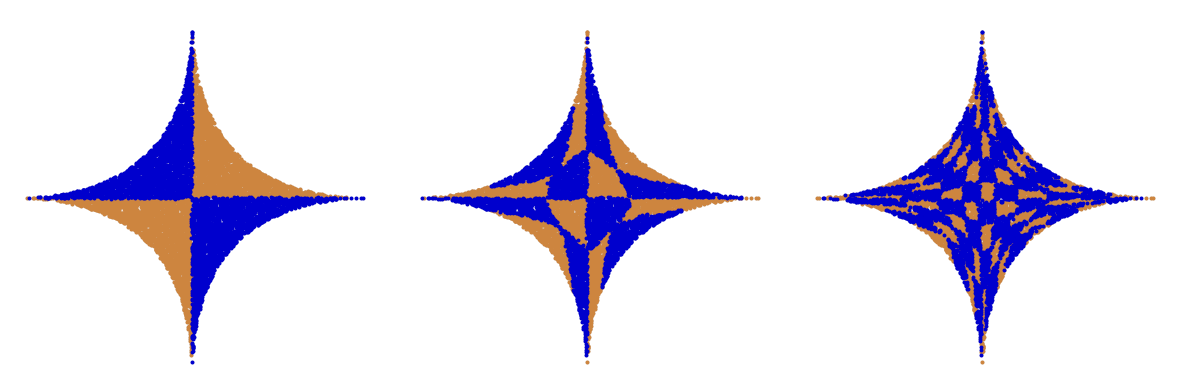

(<Figure size 1200x400 with 3 Axes>, None)

In [17]:
sn.plot(save = False)